# Trader Performance vs Market Sentiment
### Hyperliquid historical trades × Bitcoin Fear & Greed Index

**Goal:** explore how trader behaviour and performance change across market-sentiment regimes, and surface one well-supported, non-obvious insight.

**Dataset:** 211k Hyperliquid trades (32 accounts, 246 coins, May 2023 – May 2025) joined to the daily Fear/Greed classification.

**Headline finding:** these traders are systematically **contrarian** — they open mostly *long* on Fear days and mostly *short* on Greed days — and their best risk-adjusted performance comes during Extreme Greed (89% win rate on closing trades). Average PnL per trade is statistically indistinguishable between Fear and Greed; the edge is in *positioning and consistency*, not in one regime simply paying more.

In [1]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25})
ORDER=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
CMAP={'Extreme Fear':'#a4133c','Fear':'#d1495b','Neutral':'#9aa0a6','Greed':'#52b788','Extreme Greed':'#1b7a5e'}

## 1. Load, clean & merge
Trader timestamps are IST (`dd-mm-yyyy hh:mm`); we normalise to a date and left-join the sentiment label. 211,218 / 211,224 trades match — a near-perfect join.

In [2]:
h=pd.read_csv('csv_files/historical_data.csv')
h['dt']=pd.to_datetime(h['Timestamp IST'],format='%d-%m-%Y %H:%M')
h['date']=h['dt'].dt.normalize()
fg=pd.read_csv('csv_files/fear_greed_index.csv'); fg['date']=pd.to_datetime(fg['date'])
m=h.merge(fg[['date','classification','value']],on='date',how='left').dropna(subset=['classification'])
m['fg']=m['classification'].str.contains('Fear').map({True:'Fear',False:'Greed'})
m.loc[m['classification']=='Neutral','fg']='Neutral'
print(f'{len(m):,} trades matched')
m[['Account','Coin','Side','Direction','Size USD','Closed PnL','classification']].head()

211,218 trades matched


,Account,Coin,Side,Direction,Size USD,Closed PnL,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,7872.16,0.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,127.68,0.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,1150.63,0.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,1142.04,0.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,69.75,0.0,Extreme Greed


**Note on the data:** the brief mentions a `leverage` column; this export doesn't contain one, so we use `Size USD` as the position-size proxy. `Closed PnL` is non-zero only on position-closing fills (104k of 211k rows), so all profitability metrics are computed on closing trades.

## 2. Performance by sentiment regime

In [3]:
closed=m[m['Closed PnL']!=0].copy(); closed['win']=closed['Closed PnL']>0
tbl=closed.groupby('classification').agg(avg_pnl=('Closed PnL','mean'),win_rate=('win','mean'),n=('win','size')).reindex(ORDER)
tbl['avg_size_usd']=m.groupby('classification')['Size USD'].mean().reindex(ORDER)
tbl.round(3)

,avg_pnl,win_rate,n,avg_size_usd
classification,,,,
Extreme Fear,71.027,0.762,10406,5349.732
Fear,112.626,0.873,29808,7816.110
Neutral,71.200,0.824,18159,4782.733
Greed,85.404,0.769,25176,5736.884
Extreme Greed,130.205,0.892,20853,3112.252


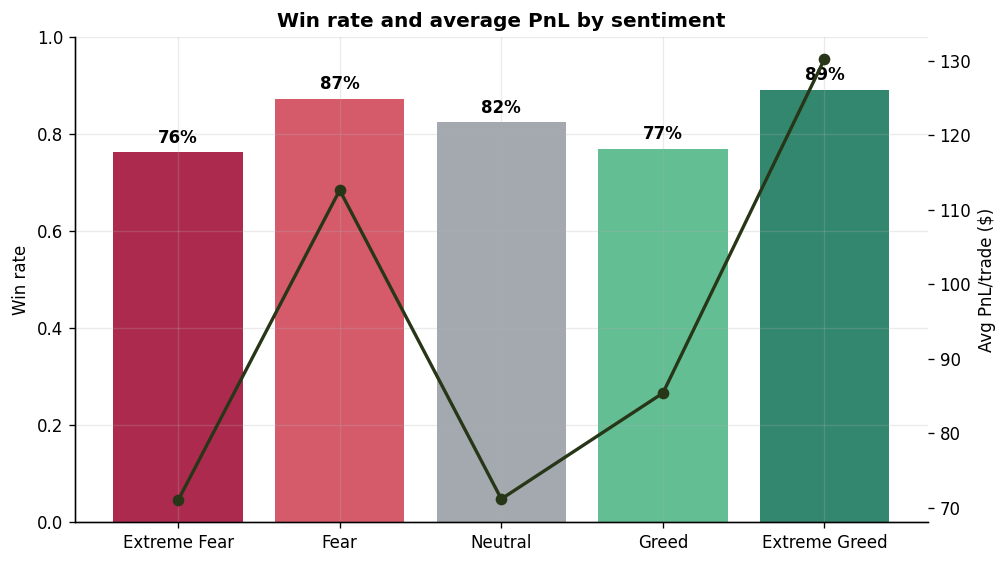

In [4]:
g=closed.groupby('classification'); wr=g['win'].mean().reindex(ORDER); pnl=g['Closed PnL'].mean().reindex(ORDER)
fig,ax1=plt.subplots(figsize=(8.5,4.8))
ax1.bar(ORDER,wr.values,color=[CMAP[c] for c in ORDER],alpha=.9); ax1.set_ylabel('Win rate'); ax1.set_ylim(0,1)
for i,v in enumerate(wr.values): ax1.text(i,v+.02,f'{v:.0%}',ha='center',weight='bold')
ax2=ax1.twinx(); ax2.plot(ORDER,pnl.values,'o-',color='#283618',lw=2); ax2.set_ylabel('Avg PnL/trade ($)'); ax2.grid(False)
ax1.set_title('Win rate and average PnL by sentiment',weight='bold'); plt.tight_layout(); plt.show()

Win rate peaks at the **extremes** (Fear 87%, Extreme Greed 89%) and sags in calm/Greed conditions. Average PnL is highest in Extreme Greed but the per-trade differences are small relative to variance — motivating the test below.

## 3. The headline: contrarian positioning

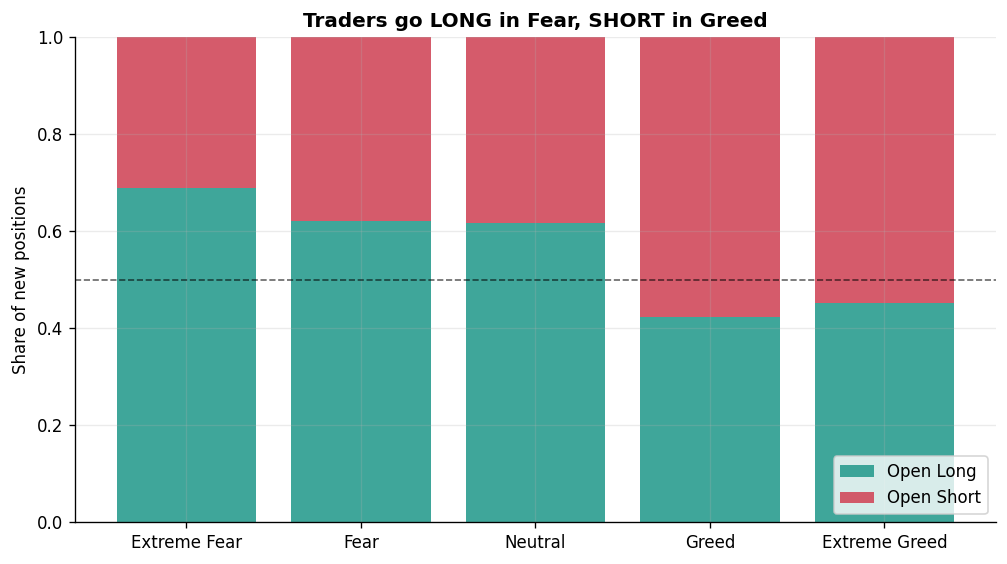

Direction,Open Long,Open Short
classification,,
Extreme Fear,0.688,0.312
Fear,0.621,0.379
Neutral,0.617,0.383
Greed,0.423,0.577
Extreme Greed,0.451,0.549


In [5]:
opens=m[m['Direction'].isin(['Open Long','Open Short'])]
mix=pd.crosstab(opens['classification'],opens['Direction'],normalize='index').reindex(ORDER)
fig,ax=plt.subplots(figsize=(8.5,4.8))
ax.bar(ORDER,mix['Open Long'],color='#2a9d8f',label='Open Long',alpha=.9)
ax.bar(ORDER,mix['Open Short'],bottom=mix['Open Long'],color='#d1495b',label='Open Short',alpha=.9)
ax.axhline(.5,color='k',ls='--',lw=1,alpha=.6); ax.set_ylim(0,1); ax.set_ylabel('Share of new positions')
ax.set_title('Traders go LONG in Fear, SHORT in Greed',weight='bold'); ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
mix.round(3)

In [6]:
o2=opens[opens['classification']!='Neutral'].copy()
o2['short']=(o2['Direction']=='Open Short').astype(int)
o2['fg']=o2['classification'].str.contains('Fear').map({True:'Fear',False:'Greed'})
chi2,p,_,_=stats.chi2_contingency(pd.crosstab(o2['fg'],o2['short']))
print(f'Direction vs Fear/Greed: chi2={chi2:.0f}, p={p:.2e}  -> positioning is strongly sentiment-dependent')

Direction vs Fear/Greed: chi2=3051, p=0.00e+00  -> positioning is strongly sentiment-dependent


On Fear days **69% of new positions in Extreme Fear are longs**; on Greed days the book flips net-short (58% short in Greed). The chi-square is decisive (p ≈ 0). This is textbook contrarian behaviour — buying fear, fading greed.

## 4. Is one regime actually more profitable? (No — and that matters)

In [7]:
f=closed[closed['fg']=='Fear']['Closed PnL']; gr=closed[closed['fg']=='Greed']['Closed PnL']
u,pm=stats.mannwhitneyu(f,gr)
print(f'Fear mean ${f.mean():.0f} vs Greed mean ${gr.mean():.0f} | Mann-Whitney p={pm:.3f}')
ra=(g['Closed PnL'].mean()/g['Closed PnL'].std()).reindex(ORDER)
print('\nRisk-adjusted return (mean/std):'); print(ra.round(3))

Fear mean $102 vs Greed mean $106 | Mann-Whitney p=0.529

Risk-adjusted return (mean/std):
classification
Extreme Fear     0.044
Fear             0.084
Neutral          0.096
Greed            0.054
Extreme Greed    0.123
Name: Closed PnL, dtype: float64


Per-trade PnL in Fear vs Greed is **not** significantly different (p=0.53). The honest takeaway: the edge is not 'trade in Fear, it pays more.' The edge is **risk-adjusted consistency** — Extreme Greed has the best mean/std (0.12) and Extreme Fear the worst (0.04), because losses fattest in Extreme Fear (avg loss −$257 vs avg win +$173).

## 5. Conclusions
1. **Positioning is sentiment-driven and contrarian** (p≈0): long in Fear, short in Greed.
2. **Win rate peaks at sentiment extremes** (~87–89%) and dips in calm markets.
3. **No raw-PnL edge between Fear and Greed** (p=0.53) — beware the common 'Fear is more profitable' over-claim.
4. **Best risk-adjusted regime is Extreme Greed**; **Extreme Fear is the most dangerous** (largest average losses), so position sizing should be cut there.
5. **Actionable strategy:** weight exposure toward the contrarian side the cohort already favours, but *down-size* in Extreme Fear where tail losses dominate.